 ## Exploratory Data Analysis (EDA)

Descargar dataset abierto, 

Convertir a csv

filtrar español

eliminar duplicados

anonimizar IDs

In [1]:
# Instalacion de Librerias
#%pip install json


In [2]:
#1 Importacion de Librerias

import pandas as pd               # Manipulación y análisis de datos; DataFrame, lectura/escritura CSV/JSON
import numpy as np                # Operaciones numéricas y arrays; utilidades estadísticas y matemáticas
import matplotlib.pyplot as plt   # Visualización básica; crear figuras, ejes y guardar gráficos
import seaborn as sns             # Visualizaciones estadísticas de alto nivel; estilos y gráficos complejos
import missingno as msno          # Visualización de datos faltantes (matrices, barras, dendrogramas)
import json                       # Leer/escribir JSON nativo; parseo y serialización
from pandas import json_normalize # Normalizar estructuras JSON anidadas a tablas planas (DataFrame)
import ast                        # Parseo seguro de literales Python (ej. convertir strings que contienen listas/dicts)
import re                         # Librería para trabajar con expresiones regulares

C:\Users\User\AppData\Local\Temp\ipykernel_23516\4018709135.py:3: DtypeWarning: Columns (0: geo, 1: coordinates) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(




=== 3. Vista preliminar de los datos ===

             name      screen_name                        location  \
0   Roberto Surur      RobertoSur5  Ciudad del Libertador General    
1          Daniel  DanielS06423561                        Atlantis   
2         احمد 🇦🇷            i_5U0            صل على نبيّنا محمّد    
3           Kevin       Thfckevin1                             NaN   
4  Dust_Free_Doug        dust_doug                  Barnet, London   

   followers_count  friends_count account_created_at        created_at  \
0              362             28   10/27/2018 17:11  12/11/2022 14:53   
1              122            376    12/10/2021 6:08  12/11/2022 14:53   
2              806            355   11/11/2017 20:08  12/11/2022 14:53   
3              333            668   11/10/2020 11:13  12/11/2022 14:53   
4               10             87    4/27/2022 23:19  12/11/2022 14:53   

             id                                          full_text  truncated  \
0  1.6019

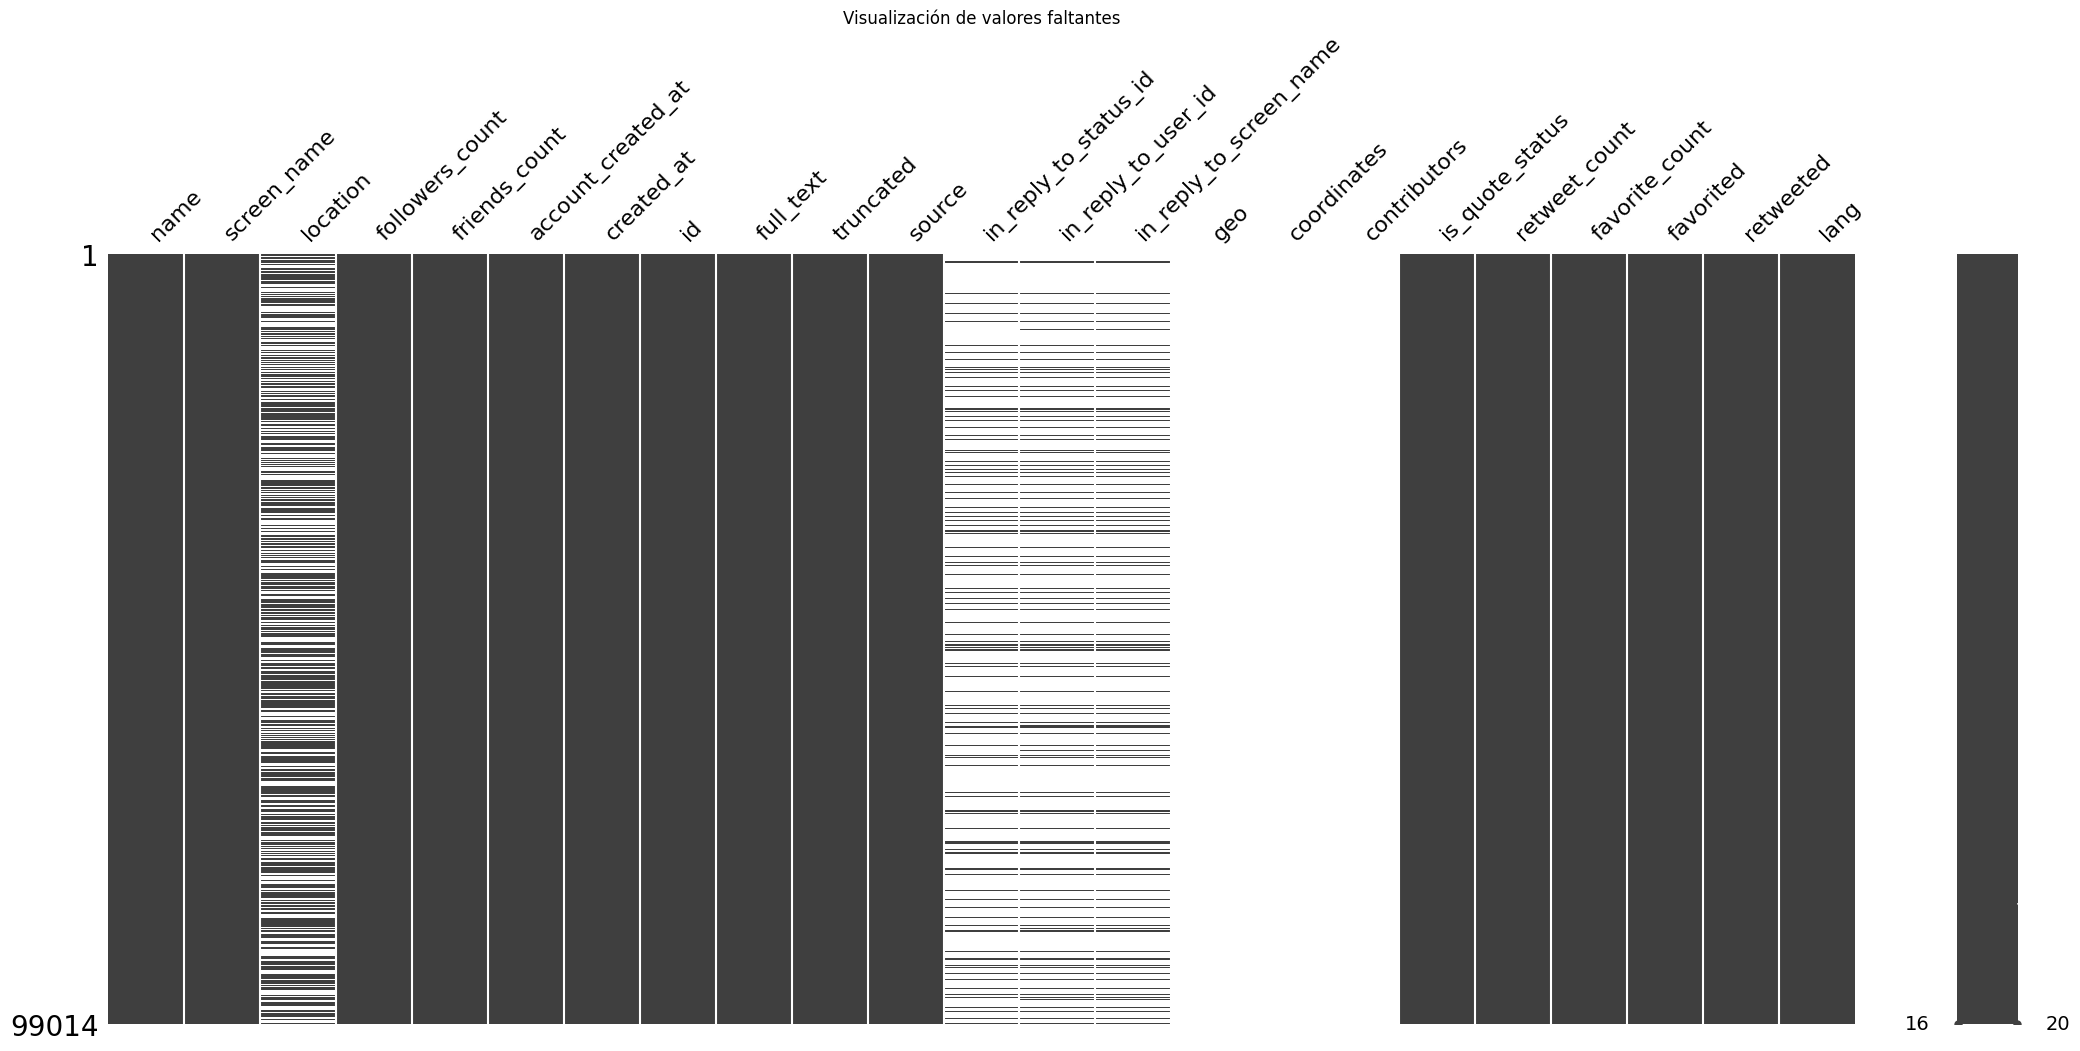

In [3]:
# =======================================================================
#2 Cargar dataset (ajusta el nombre según lo que descargues)
df = pd.read_csv(
    "data/twtdata.com_tweets_by_hashtag_Fifa_Xd8b0u2i9n.csv",
    sep=",",          # usa tab como separador 
    encoding="utf-8", # prueba utf-8, si falla usa latin1
    on_bad_lines="skip" # ignora filas mal formateadas
)

# =======================================================================
#3 Vista preliminar de los datos
print("\n\n=== 3. Vista preliminar de los datos ===\n")
# Revisamos las primeras filas, últimas filas y una muestra aleatoria
# para entender la estructura general del dataset.
print(df.head())


# =======================================================================
# 4. Dimensiones y tipos de datos
print("\n\n=== 4. Dimensiones y tipos de datos ===\n")
# shape devuelve número de filas y columnas.
# dtypes muestra el tipo de dato de cada columna (numérico, texto, etc.).
print("Dimensiones:", df.shape)
print("Tipos de datos:\n", df.dtypes)

# =======================================================================
# 5. Estadísticas básicas
print("\n\n=== 5. Estadísticas básicas ===\n")
# describe() genera estadísticas descriptivas de columnas numéricas
# y con include="all" también incluye categóricas.
print(df.describe(include="all"))

# =======================================================================
# 6. Análisis de datos faltantes
print("\n\n=== 6. Análisis de datos faltantes ===\n\n")
# isnull().sum() cuenta valores nulos por columna.
print("Valores nulos por columna:\n", df.isnull().sum())

# Visualización de valores faltantes con missingno
# Esto ayuda a identificar patrones de ausencia de datos.
msno.matrix(df)
plt.title("Visualización de valores faltantes")
plt.show()


In [14]:
# =======================================================================
# 7. Eliminar columnas con más del 95% de valores nulos + columnas sensibles

# Calculamos el porcentaje de valores nulos por columna
threshold = 0.95
null_ratio = df.isnull().mean()

# Seleccionamos las columnas cuyo porcentaje de nulos es mayor al 95%
cols_to_drop = null_ratio[null_ratio > threshold].index.tolist()

# Definimos explícitamente columnas sensibles que contienen datos personales
cols_sensitive = ["id", "name", "screen_name", "location"]

# Unimos ambas listas (nulos + sensibles)
cols_to_drop = list(set(cols_to_drop + cols_sensitive))

# Eliminamos esas columnas del dataframe
df = df.drop(columns=cols_to_drop, errors="ignore")
print("Columnas eliminadas:", cols_to_drop)

# =======================================================================
# 8. Filtrar tweets en español y eliminar duplicados/retweets

# Nos quedamos solo con los tweets cuyo idioma es español
df_es = df[df["lang"] == "es"].copy()

# Eliminamos duplicados basados en el texto completo del tweet
df_es = df_es.drop_duplicates(subset=["full_text"])

# Eliminamos los retweets (columna booleana 'retweeted')
df_es = df_es[df_es["retweeted"] == False]

print("Tweets en español después de limpieza:", len(df_es))

# =======================================================================
# 9. Anonimización de identificadores

import hashlib  # Librería para aplicar funciones hash

# Definimos función que convierte un texto en un hash SHA-256
def hash_text(x):
    return hashlib.sha256(str(x).encode("utf-8")).hexdigest()

# Creamos un identificador interno estable combinando texto + fecha de creación
df_es["tweet_id_hashed"] = (df_es["full_text"] + df_es["created_at"]).apply(hash_text)

# =======================================================================
# 10. Guardar corpus canónico

# Definimos la ruta de salida del corpus canónico
output_path = "data/corpus_canonical_v1.jsonl" #"C:/Users/User/Documents/Maestria/TFM/TFM/data/corpus_canonical_v1.jsonl"

# Guardamos el dataframe en formato JSONL (una línea por registro)
df_es.to_json(output_path, orient="records", lines=True, force_ascii=False)

# =======================================================================
# 11. Generar checksum del archivo

# Función para calcular el hash SHA-256 de un archivo completo
def file_checksum(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            h.update(chunk)
    return h.hexdigest()

# Calculamos el checksum del corpus guardado
checksum = file_checksum(output_path)

# Guardamos el checksum en un archivo de texto
with open("data/checksum.txt", "w") as f:
    f.write("sha256:" + checksum)

# Mensaje final de confirmación
print("Corpus canónico guardado con", len(df_es), "tweets en español y IDs anonimizados.")

print("\n\n=== Checksum (SHA-256) ===\n")
print("sha256:",checksum)



Columnas eliminadas: ['screen_name', 'name', 'location', 'id']
Tweets en español después de limpieza: 6437
Corpus canónico guardado con 6437 tweets en español y IDs anonimizados.


=== Checksum (SHA-256) ===

sha256: e97da11f850e569f7e326cff61ed63ad9b9f9fa0dea74d5edcf634bf0fe12bb9


In [5]:
# 12. =======================================================================
# Verificación final del corpus

# Mostrar las columnas restantes después de la limpieza
print("\n=== Columnas finales del corpus ===")
print(df_es.columns.tolist())

# Mostrar las primeras filas para verificar estructura y anonimización
print("\n=== Primeras filas del corpus limpio ===")
print(df_es.head())

# Confirmar que las columnas sensibles ya no están
cols_sensitive = ["id", "name", "screen_name", "location"]
for col in cols_sensitive:
    if col in df_es.columns:
        print(f"⚠️ La columna {col} todavía está presente.")
    else:
        print(f"✔ La columna {col} fue eliminada correctamente.")



=== Columnas finales del corpus ===
['followers_count', 'friends_count', 'account_created_at', 'created_at', 'full_text', 'truncated', 'source', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'is_quote_status', 'retweet_count', 'favorite_count', 'favorited', 'retweeted', 'lang', 'tweet_id_hashed']

=== Primeras filas del corpus limpio ===
    followers_count  friends_count account_created_at        created_at  \
0               362             28   10/27/2018 17:11  12/11/2022 14:53   
1               122            376    12/10/2021 6:08  12/11/2022 14:53   
12              136           1849   10/27/2017 10:23  12/11/2022 14:53   
17              149            167     7/5/2021 21:11  12/11/2022 14:53   
18            26986            886    4/30/2014 18:56  12/11/2022 14:53   

                                            full_text  truncated  \
0   RT @eldestapeweb: 🔴 La FIFA abrió un expedient...      False   
1   RT @estarc62: En el 66 insultando a la 



# RESUMEN ESTADISTICO BASICO



In [6]:
# 13. =======================================================================
# RESUMEN ESTADISTICO BASICO

print("\n=== # RESUMEN ESTADISTICO BASICO ===\n")

# Columnas originales
print("\n=== Columnas Dataset Original ===\n")
print(df.columns.tolist())

# Columnas del corpus limpio
print("\n=== Columnas del corpus limpio ===\n")
print(df_es.columns.tolist())

# Número total de tweets
print("\nTotal de tweets en español:", len(df_es))

# Distribución por idioma (aunque ya filtramos, sirve para verificar)
print("\n=== Distribución por idioma ===")
print(df_es['lang'].value_counts())

# Longitud promedio de los tweets (usar 'full_text')
df_es['tweet_length'] = df_es['full_text'].apply(lambda x: len(str(x)))
print("\n=== Longitud promedio de los tweets ===")
print(df_es['tweet_length'].mean())


# 13.1. =======================================================================
# EXTRACCIÓN DE HASHTAGS Y MULTIMEDIA DESDE EL TEXTO

# Extraer hashtags directamente del texto de los tweets usando regex
# La expresión r"#\w+" busca cualquier palabra precedida por el símbolo #
df_es['extracted_hashtags'] = df_es['full_text'].apply(
    lambda x: re.findall(r"#\w+", str(x))
)

# Unimos todas las listas de hashtags en una sola lista
all_hashtags = df_es['extracted_hashtags'].sum()

# Convertimos la lista en una Serie de pandas para poder contar frecuencias
hashtags_series = pd.Series(all_hashtags)

# Mostramos los 10 hashtags más frecuentes en el corpus
print("\n=== Top 10 hashtags más frecuentes ===")
print(hashtags_series.value_counts().head(10))

# Detectar enlaces a imágenes en el texto
# 'pic.twitter.com' es el patrón típico de imágenes compartidas en tweets
df_es['has_image'] = df_es['full_text'].apply(lambda x: 'pic.twitter.com' in str(x))

# Detectar enlaces a videos en el texto
# Buscamos palabras clave como 'video' o enlaces a YouTube ('youtu')
df_es['has_video'] = df_es['full_text'].apply(
    lambda x: 'video' in str(x).lower() or 'youtu' in str(x).lower()
)

# Mostramos el conteo de tweets que contienen multimedia
print("\n=== Tweets con multimedia detectada ===")
print("Con imagen:", df_es['has_image'].sum())
print("Con video:", df_es['has_video'].sum())



"""
# Hashtags más frecuentes (solo si existe la columna 'hashtags')
if 'hashtags' in df_es.columns:
    try:
        # Convertir listas de hashtags en una sola lista
        all_hashtags = df_es['hashtags'].dropna().apply(eval).sum()
        hashtags_series = pd.Series(all_hashtags)
        print("\n=== Top 10 hashtags más frecuentes ===")
        print(hashtags_series.value_counts().head(10))
    except Exception as e:
        print("Error procesando hashtags:", e)

# Tweets con imágenes y videos (solo si existen esas columnas)
if 'is_image' in df_es.columns and 'is_video' in df_es.columns:
    print("\n=== Tweets con multimedia ===")
    print("Con imagen:", df_es['is_image'].astype(int).sum())
    print("Con video:", df_es['is_video'].astype(int).sum())
"""


=== # RESUMEN ESTADISTICO BASICO ===


=== Columnas Dataset Original ===

['followers_count', 'friends_count', 'account_created_at', 'created_at', 'full_text', 'truncated', 'source', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'is_quote_status', 'retweet_count', 'favorite_count', 'favorited', 'retweeted', 'lang']

=== Columnas del corpus limpio ===

['followers_count', 'friends_count', 'account_created_at', 'created_at', 'full_text', 'truncated', 'source', 'in_reply_to_status_id', 'in_reply_to_user_id', 'in_reply_to_screen_name', 'is_quote_status', 'retweet_count', 'favorite_count', 'favorited', 'retweeted', 'lang', 'tweet_id_hashed']

Total de tweets en español: 6437

=== Distribución por idioma ===
lang
es    6437
Name: count, dtype: int64

=== Longitud promedio de los tweets ===
161.91424576666148

=== Top 10 hashtags más frecuentes ===
#Qatar2022           293
#FIFA                134
#FIFAWorldCup         97
#MacriMufa            50
#VTV            

'\n# Hashtags más frecuentes (solo si existe la columna \'hashtags\')\nif \'hashtags\' in df_es.columns:\n    try:\n        # Convertir listas de hashtags en una sola lista\n        all_hashtags = df_es[\'hashtags\'].dropna().apply(eval).sum()\n        hashtags_series = pd.Series(all_hashtags)\n        print("\n=== Top 10 hashtags más frecuentes ===")\n        print(hashtags_series.value_counts().head(10))\n    except Exception as e:\n        print("Error procesando hashtags:", e)\n\n# Tweets con imágenes y videos (solo si existen esas columnas)\nif \'is_image\' in df_es.columns and \'is_video\' in df_es.columns:\n    print("\n=== Tweets con multimedia ===")\n    print("Con imagen:", df_es[\'is_image\'].astype(int).sum())\n    print("Con video:", df_es[\'is_video\'].astype(int).sum())\n'

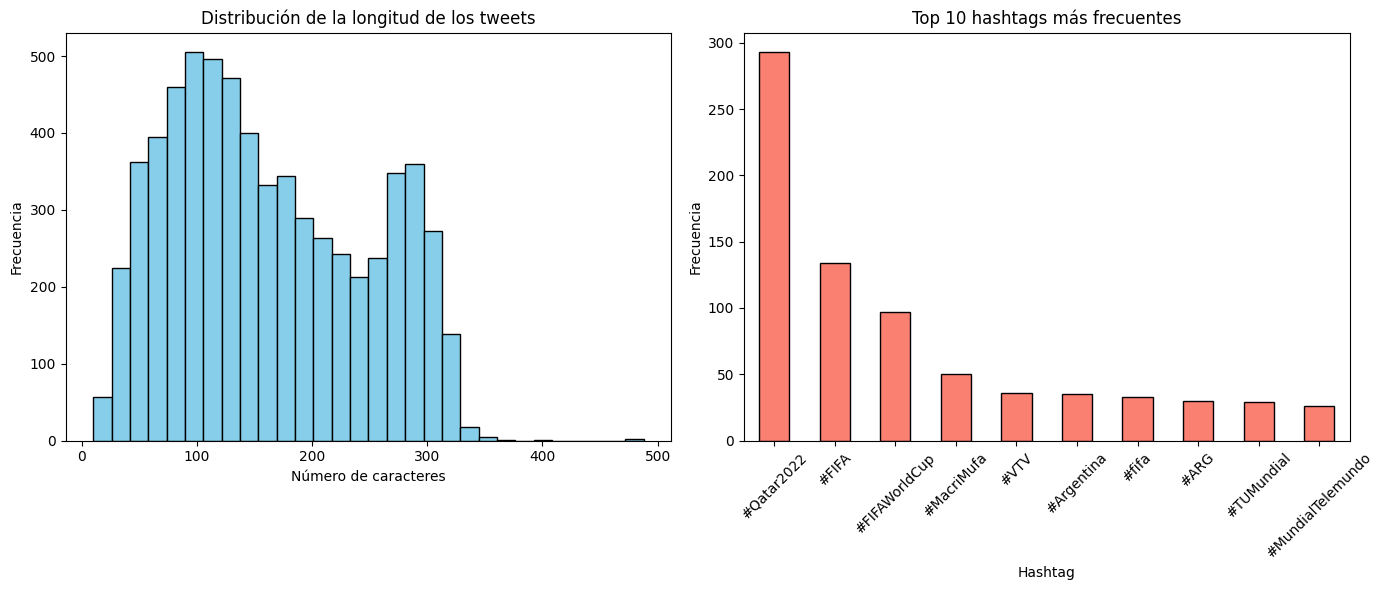

In [7]:
# 14. =======================================================================
# VISUALIZACIONES BÁSICAS

# VISUALIZACIÓN COMBINADA: LONGITUDES DE TWEETS + HASHTAGS FRECUENTES

# --- Preparar datos para hashtags ---
# Unimos todas las listas de hashtags en una sola lista
all_hashtags = df_es['extracted_hashtags'].sum()

# Convertimos la lista en una Serie de pandas para contar frecuencias
hashtags_series = pd.Series(all_hashtags)

# Seleccionamos los 10 hashtags más frecuentes
top_hashtags = hashtags_series.value_counts().head(10)

# --- Crear figura con dos subplots ---
plt.figure(figsize=(14,6))  # Definimos tamaño general de la figura

# Subplot 1: Histograma de longitudes de tweets
plt.subplot(1,2,1)  # 1 fila, 2 columnas, posición 1
plt.hist(df_es['tweet_length'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribución de la longitud de los tweets")
plt.xlabel("Número de caracteres")
plt.ylabel("Frecuencia")

# Subplot 2: Gráfico de barras de hashtags más frecuentes
plt.subplot(1,2,2)  # 1 fila, 2 columnas, posición 2
top_hashtags.plot(kind='bar', color='salmon', edgecolor='black')
plt.title("Top 10 hashtags más frecuentes")
plt.xlabel("Hashtag")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)

# Ajustamos el diseño para que no se solapen los gráficos
plt.tight_layout()

# Mostramos la figura completa
plt.show()
